In [1]:
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [93]:
memory_type = torch.device('cuda')
dtype = torch.float32
num_modes = 1
study = 'TE'

# device 1

In [94]:
# # parameters
# lambd = 1.55
# 
# # wave number and normalized spacing
# k_0 = 2 * np.pi / lambd
# 
# # device 1
# 
# # spacing
# dx = 0.05 * k_0
# dy = 0.05 * k_0
# 
# # simulation lengths
# core_length_x = 1 * k_0 # W
# core_length_y = 1 * k_0 # H
# 
# substrate_length_x = 3.0 * k_0 # Xs
# substrate_length_y = 3.0 * k_0 # Ys
# 
# # refractive indices
# n_core = 3
# n_substrate = 1

In [95]:
# # parameters
# lambd = 1.55
# 
# # wave number and normalized spacing
# k_0 = 2 * np.pi / lambd
# 
# # device 2
# 
# # spacing
# dx = 0.05 * k_0
# dy = 0.05 * k_0
# 
# # simulation lengths
# core_length_x = 2 * k_0 # W
# core_length_y = 1 * k_0 # H
# 
# substrate_length_x = 3.0 * k_0 # Xs
# substrate_length_y = 3.0 * k_0 # Ys
# 
# # refractive indices
# n_core = 2
# n_substrate = 1

In [118]:
# parameters
lambd = 1.55

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 2

# spacing
dx = lambd/50 * k_0
dy = lambd/50 * k_0

# simulation lengths
core_length_x = 3/4 * lambd * k_0 # W
core_length_y = 3/2 * lambd * k_0 # H

substrate_length_x = 2.0 * lambd * k_0 # Xs
substrate_length_y = 2.0 * lambd * k_0 # Ys

# refractive indices
n_core = 3
n_substrate = 1

In [119]:
weights = [1/2, 1/2, 6, 1/4, 1, 1]
m = 2

In [120]:
lengths_x = [substrate_length_x, core_length_x, substrate_length_x]
lengths_y = [substrate_length_y, core_length_y, substrate_length_y]
RIs = [n_substrate, n_core]

In [121]:
reference_device = guides.BuriedChannelWaveguide(RIs, lambd, lengths_x, lengths_y, study, 'E')

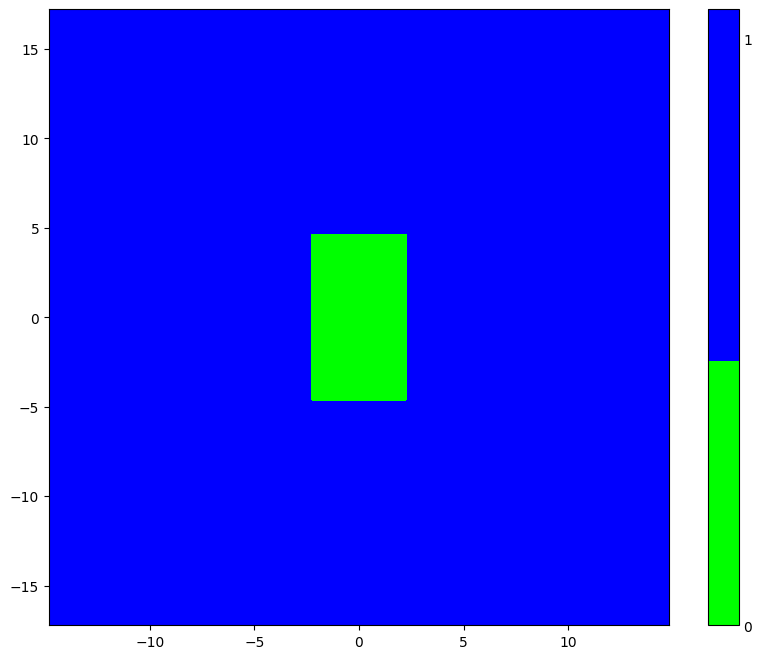

In [122]:
reference_device.plot(dx, dy)

In [123]:
torch.manual_seed(42)
base_model = models.discontinuity_capturing_network(2, 256, num_modes, 2, 'Siren')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=8e-3)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[9000], gamma=1e-1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 67073


In [124]:
# mesh = samplers.uniform_grid_2d(reference_device, dx/2, dy/2, dtype, 'cpu')
# features = reference_device.make_features(mesh)
# 
# plt.scatter(mesh[:, 0].cpu().detach(), mesh[:, 1].cpu().detach(), s=1, c=features, cmap='jet');

In [125]:
device = guides.BuriedChannelWaveguideWithPINNs(RIs, lambd, lengths_x, lengths_y, study, 'E', base_model, 1, True)

In [126]:
reference_device_fd = guides.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy)

In [127]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=2, n_upper=None)

  0%|          | 0/11001 [00:00<?, ?it/s]

num samples 65175


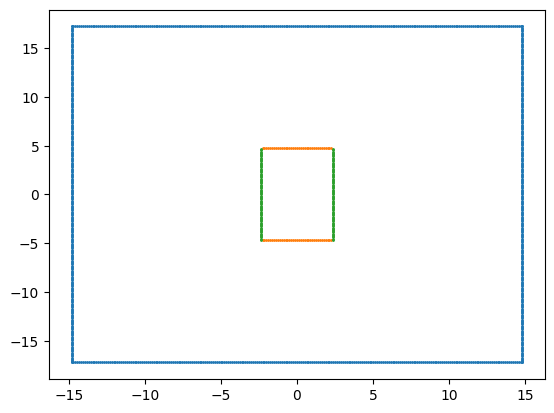

loss1 is  0.14747, loss2 is  0.00058, loss3 is  0.30356, loss4 is  0.00000, loss5 is  0.03945, loss6 is  0.04222, total loss  0.53329, RI value  1.19544:   0%|          | 0/11001 [00:01<?, ?it/s]

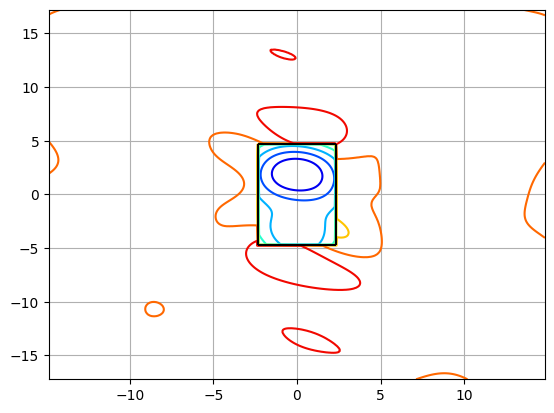

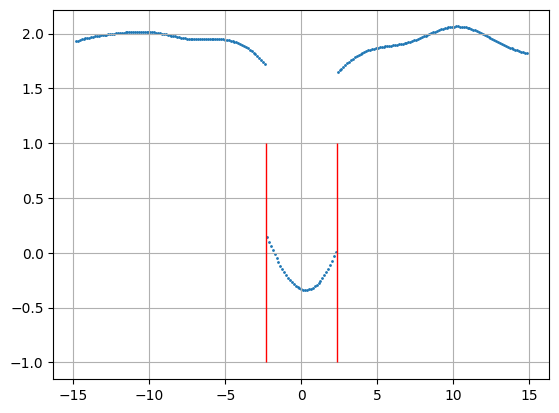

loss1 is  0.91476, loss2 is  0.00000, loss3 is  0.47151, loss4 is  0.00000, loss5 is  0.01818, loss6 is  0.03499, total loss  1.43945, RI value  2.94964:   5%|▍         | 500/11001 [01:00<20:29,  8.54it/s]

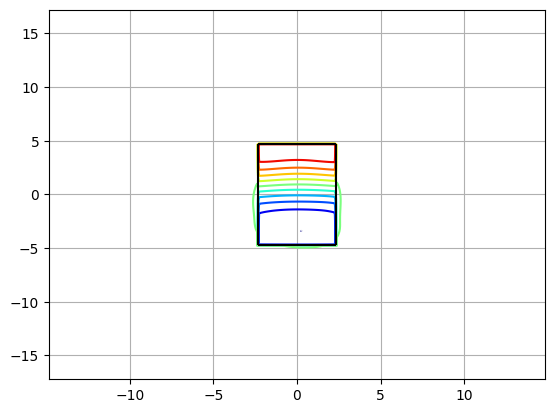

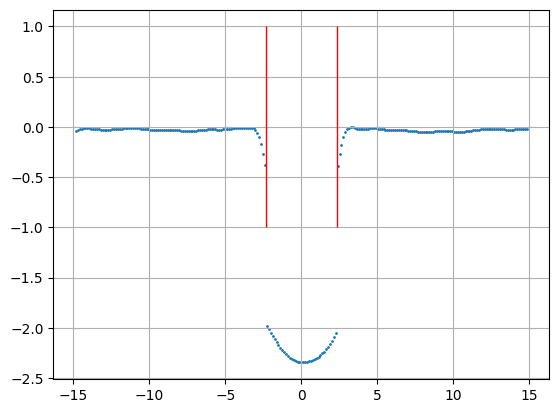

loss1 is  0.44886, loss2 is  0.00001, loss3 is  0.23203, loss4 is  0.00000, loss5 is  0.00712, loss6 is  0.02646, total loss  0.71448, RI value  2.94493:   9%|▉         | 1000/11001 [01:59<19:13,  8.67it/s] 

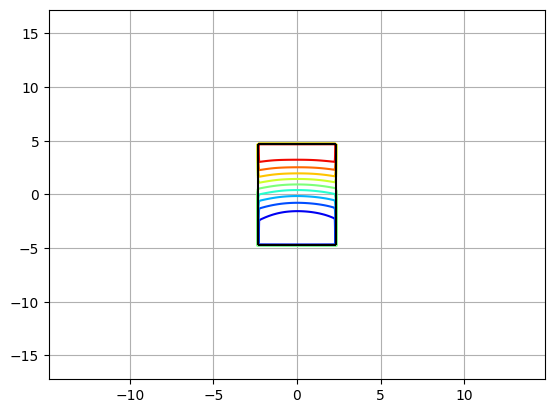

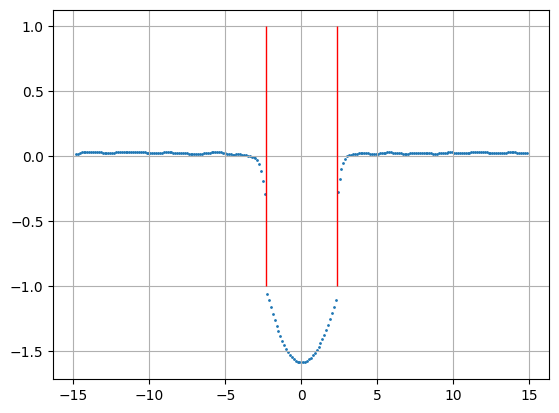

loss1 is  0.26125, loss2 is  0.00003, loss3 is  0.13390, loss4 is  0.00000, loss5 is  0.00272, loss6 is  0.01882, total loss  0.41672, RI value  2.95891:  14%|█▎        | 1500/11001 [02:58<18:31,  8.55it/s]

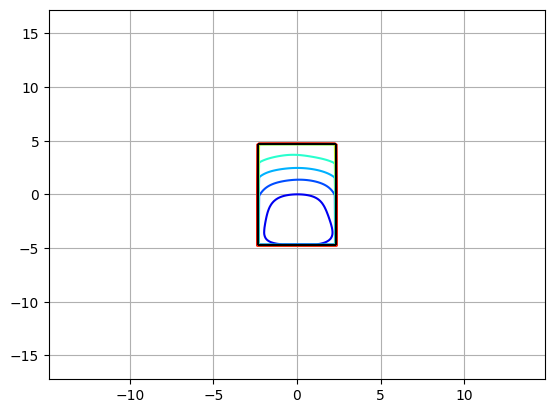

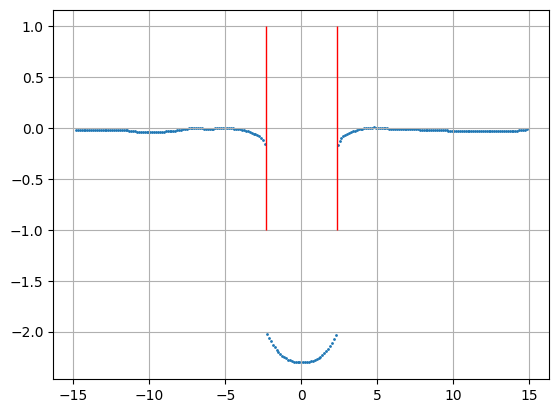

loss1 is  0.14243, loss2 is  0.00006, loss3 is  0.07250, loss4 is  0.00000, loss5 is  0.00142, loss6 is  0.02018, total loss  0.23658, RI value  2.97041:  18%|█▊        | 2000/11001 [03:57<17:23,  8.63it/s]

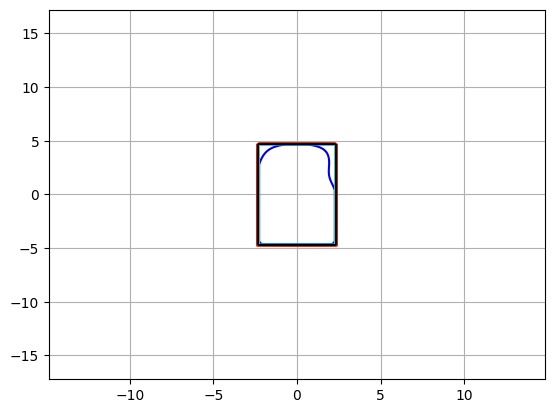

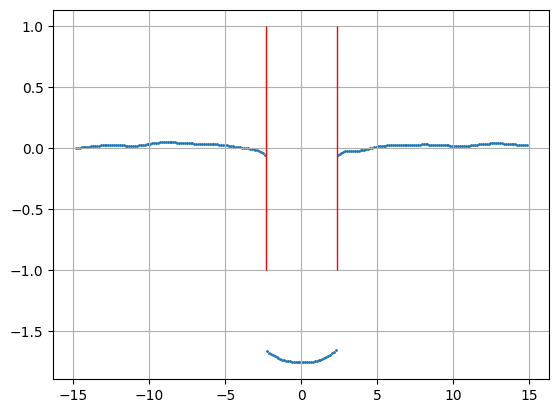

loss1 is  0.01239, loss2 is  0.00113, loss3 is  0.00645, loss4 is  0.00000, loss5 is  0.00018, loss6 is  0.00681, total loss  0.02696, RI value  2.93356:  23%|██▎       | 2500/11001 [04:57<16:38,  8.51it/s]

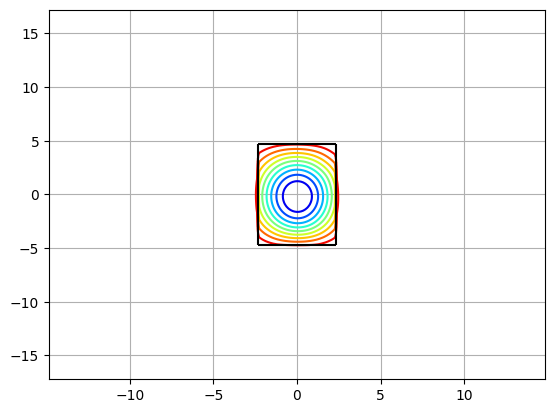

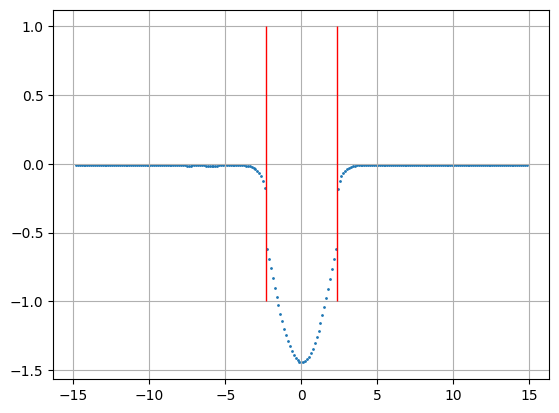

loss1 is  0.01603, loss2 is  0.00080, loss3 is  0.00834, loss4 is  0.00000, loss5 is  0.00017, loss6 is  0.00656, total loss  0.03190, RI value  2.93485:  27%|██▋       | 3000/11001 [05:56<15:28,  8.61it/s]

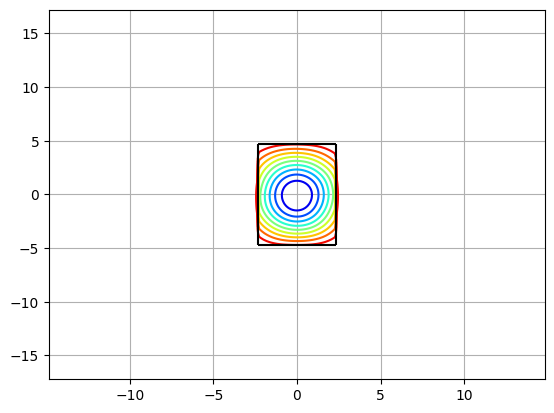

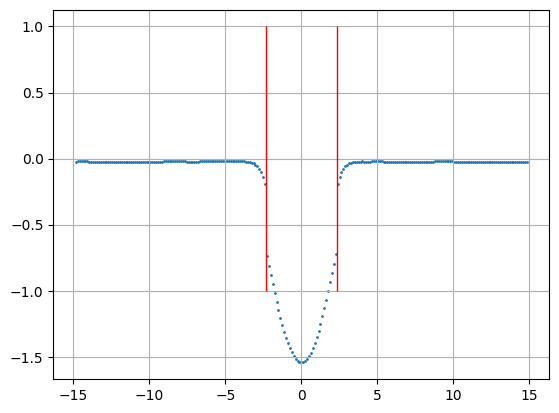

loss1 is  0.01031, loss2 is  0.00085, loss3 is  0.00534, loss4 is  0.00000, loss5 is  0.00012, loss6 is  0.00735, total loss  0.02397, RI value  2.94121:  32%|███▏      | 3500/11001 [06:55<14:29,  8.62it/s]

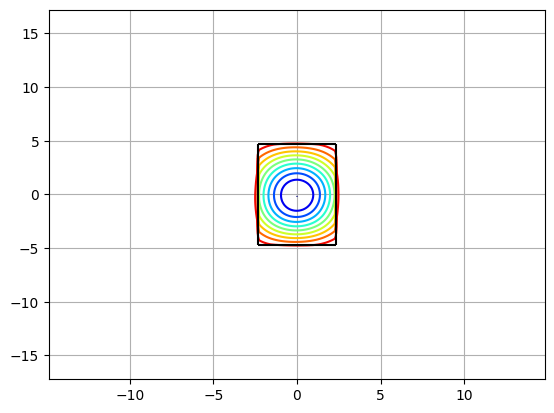

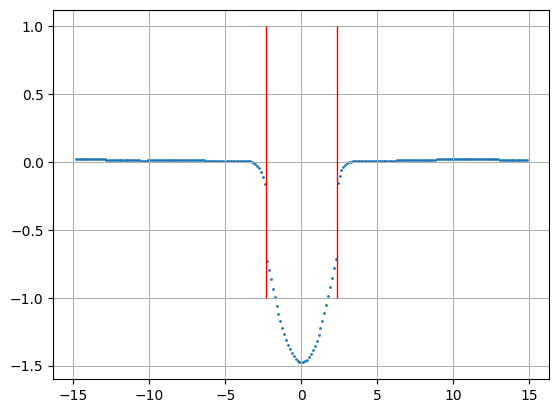

loss1 is  0.02892, loss2 is  0.00104, loss3 is  0.01512, loss4 is  0.00000, loss5 is  0.00044, loss6 is  0.00715, total loss  0.05267, RI value  2.92614:  36%|███▋      | 4000/11001 [07:54<13:40,  8.53it/s]

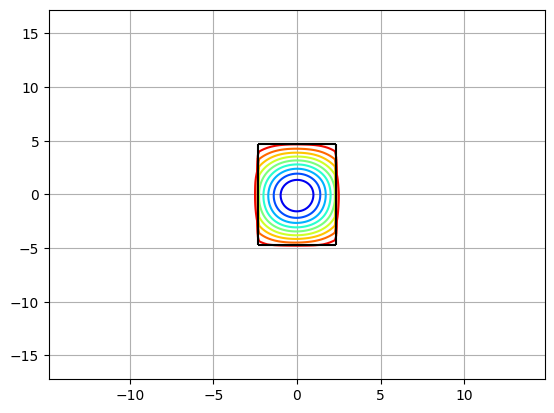

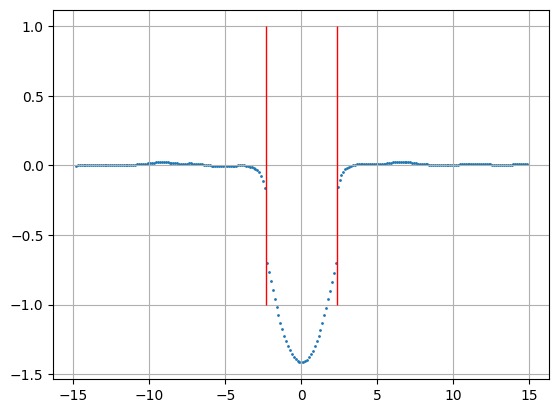

loss1 is  0.01497, loss2 is  0.00108, loss3 is  0.00779, loss4 is  0.00000, loss5 is  0.00020, loss6 is  0.00646, total loss  0.03050, RI value  2.93379:  41%|████      | 4500/11001 [08:53<12:58,  8.35it/s]

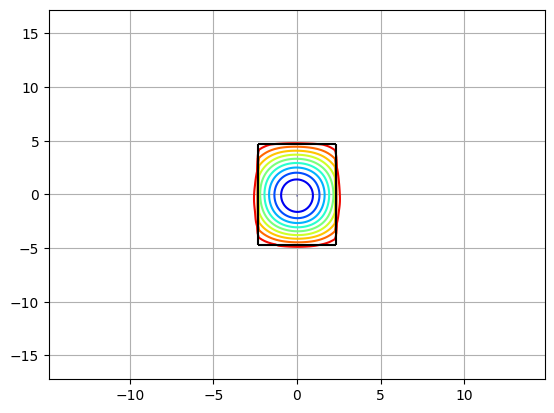

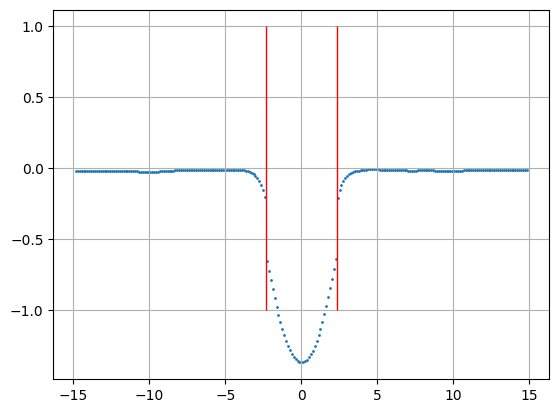

loss1 is  0.00140, loss2 is  0.00087, loss3 is  0.00073, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00622, total loss  0.00922, RI value  2.92940:  45%|████▌     | 5000/11001 [09:53<11:38,  8.59it/s]

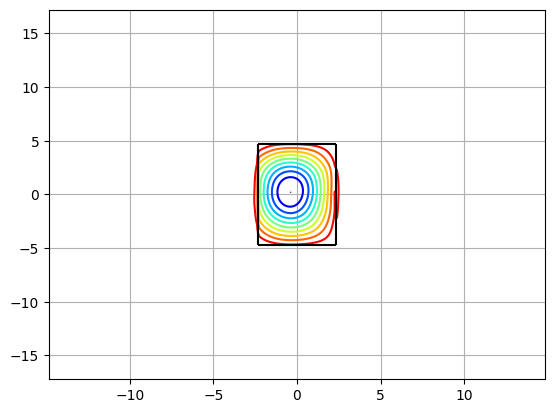

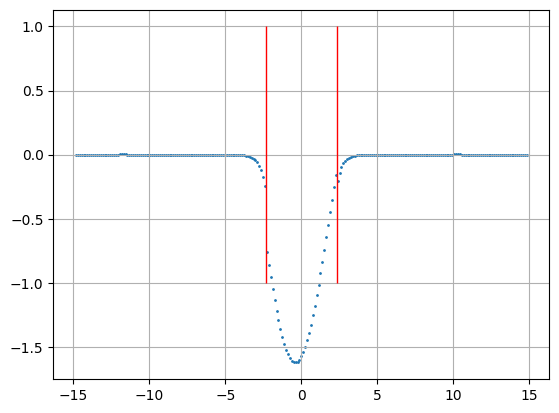

loss1 is  0.00247, loss2 is  0.00076, loss3 is  0.00129, loss4 is  0.00000, loss5 is  0.00003, loss6 is  0.00516, total loss  0.00972, RI value  2.92222:  50%|████▉     | 5500/11001 [10:53<10:43,  8.55it/s]

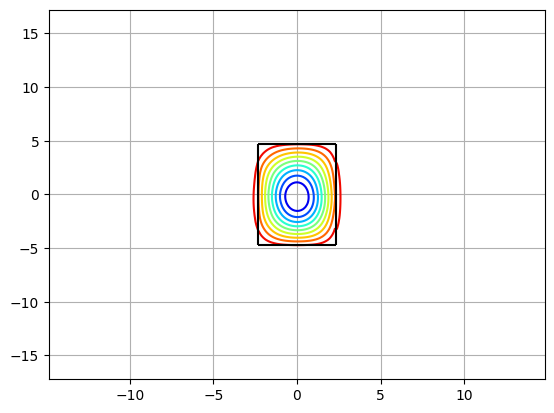

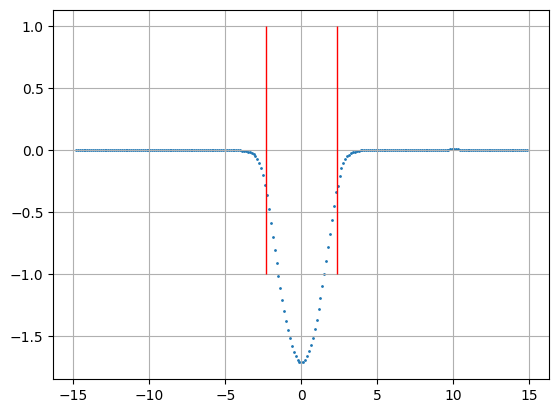

loss1 is  0.00313, loss2 is  0.00126, loss3 is  0.00166, loss4 is  0.00000, loss5 is  0.00003, loss6 is  0.04514, total loss  0.05122, RI value  2.90476:  55%|█████▍    | 6000/11001 [11:52<09:39,  8.63it/s]

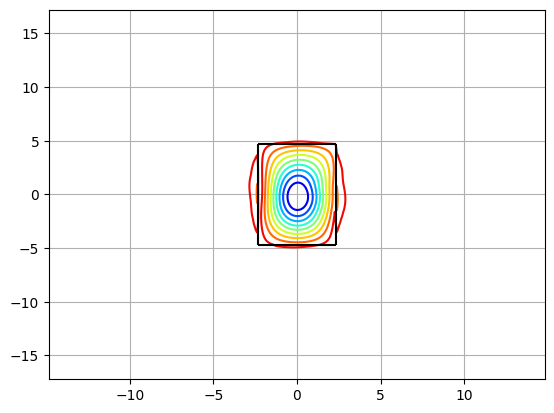

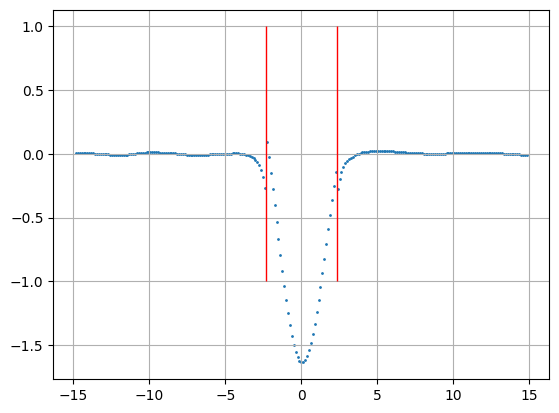

loss1 is  0.00106, loss2 is  0.00067, loss3 is  0.00056, loss4 is  0.00000, loss5 is  0.00001, loss6 is  0.00592, total loss  0.00822, RI value  2.92088:  59%|█████▉    | 6500/11001 [12:51<08:49,  8.49it/s]

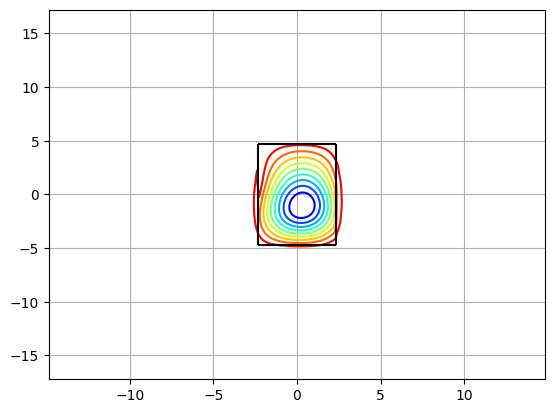

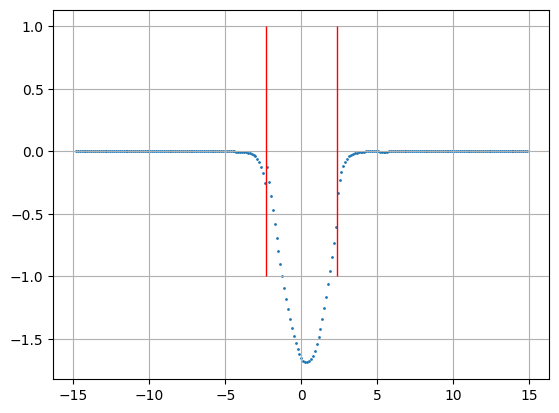

loss1 is  0.00363, loss2 is  0.00091, loss3 is  0.00190, loss4 is  0.00000, loss5 is  0.00003, loss6 is  0.00582, total loss  0.01231, RI value  2.92131:  64%|██████▎   | 7000/11001 [13:51<07:59,  8.34it/s]

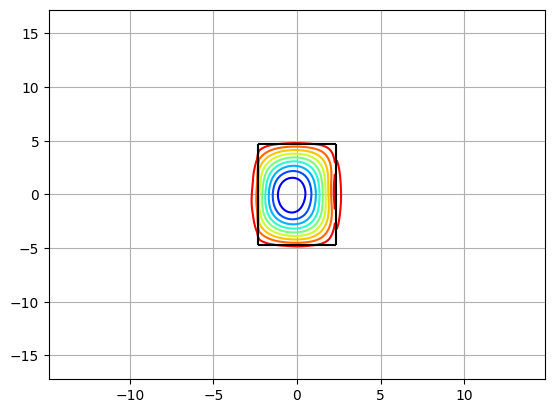

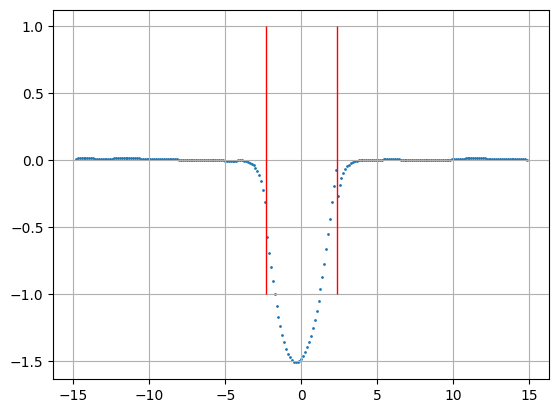

loss1 is  0.00175, loss2 is  0.00087, loss3 is  0.00092, loss4 is  0.00000, loss5 is  0.00002, loss6 is  0.00077, total loss  0.00433, RI value  2.90884:  68%|██████▊   | 7500/11001 [14:50<06:59,  8.35it/s]

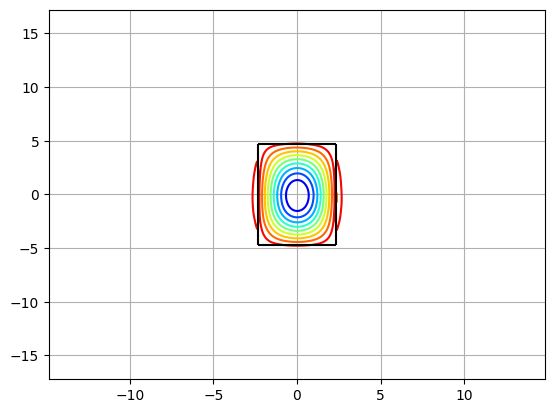

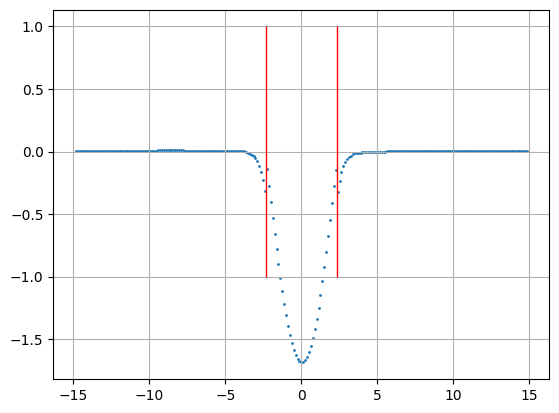

loss1 is  0.00208, loss2 is  0.00073, loss3 is  0.00110, loss4 is  0.00000, loss5 is  0.00002, loss6 is  0.00039, total loss  0.00431, RI value  2.90885:  73%|███████▎  | 8000/11001 [15:50<05:59,  8.34it/s]

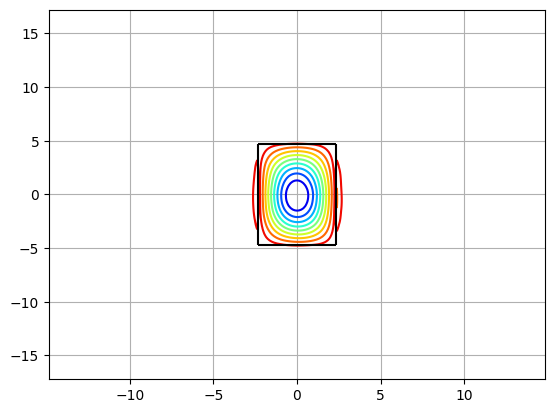

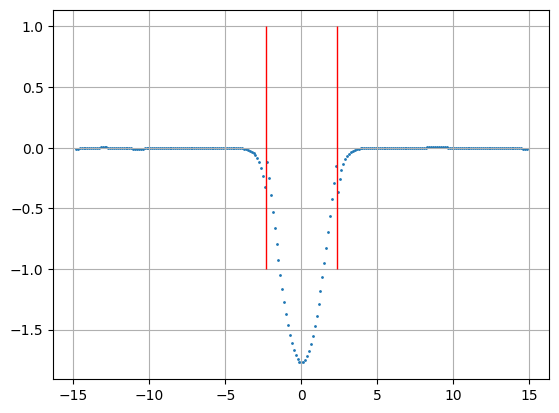

loss1 is  0.00337, loss2 is  0.00063, loss3 is  0.00178, loss4 is  0.00000, loss5 is  0.00004, loss6 is  0.00075, total loss  0.00658, RI value  2.90831:  77%|███████▋  | 8500/11001 [16:50<04:54,  8.48it/s]

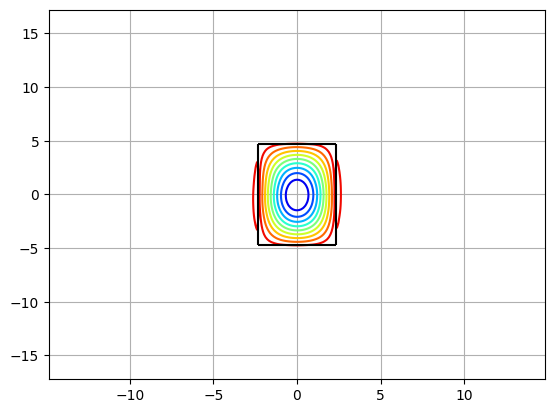

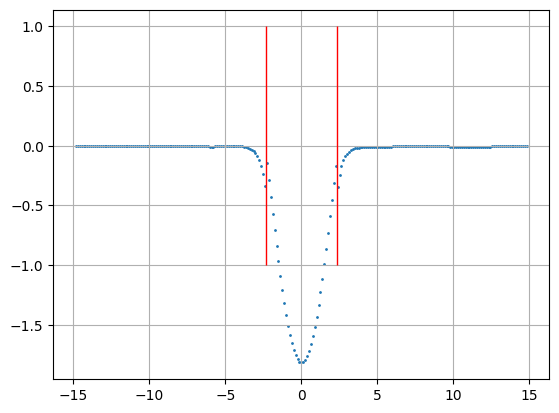

loss1 is  0.00449, loss2 is  0.00081, loss3 is  0.00237, loss4 is  0.00000, loss5 is  0.00004, loss6 is  0.00192, total loss  0.00964, RI value  2.91139:  82%|████████▏ | 9000/11001 [17:49<03:57,  8.43it/s]

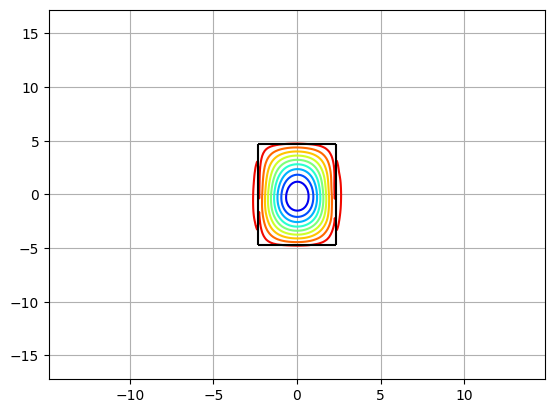

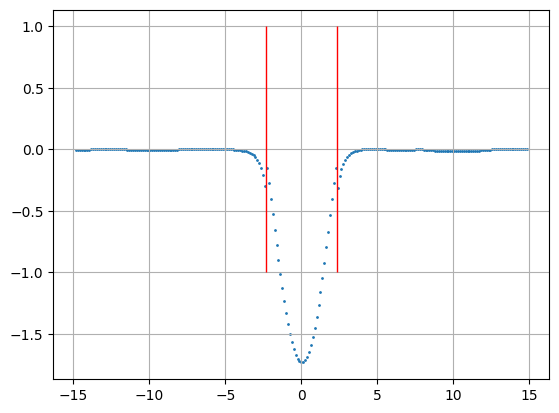

loss1 is  0.00028, loss2 is  0.00066, loss3 is  0.00015, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00012, total loss  0.00122, RI value  2.91024:  86%|████████▋ | 9500/11001 [18:49<03:01,  8.28it/s]

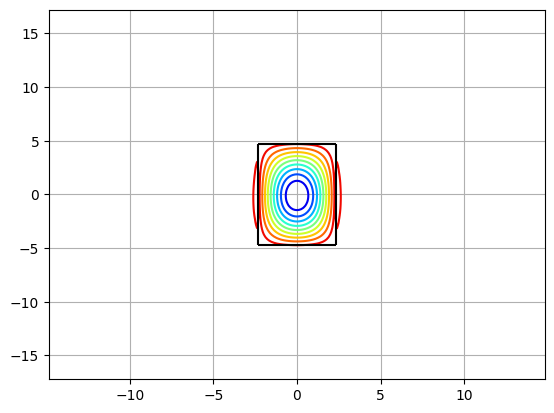

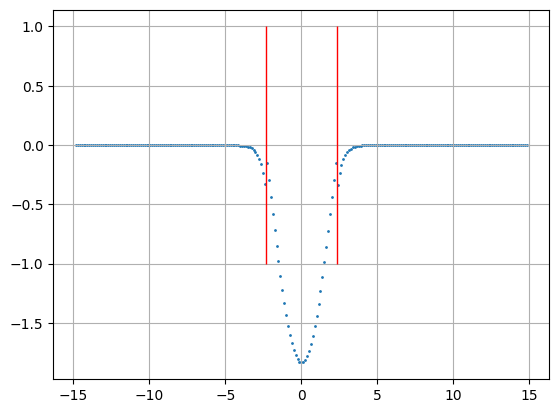

loss1 is  0.00074, loss2 is  0.00057, loss3 is  0.00039, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00014, total loss  0.00185, RI value  2.91011:  91%|█████████ | 10000/11001 [19:49<01:58,  8.48it/s]

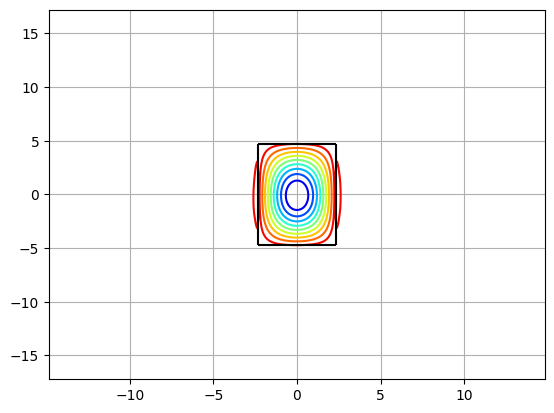

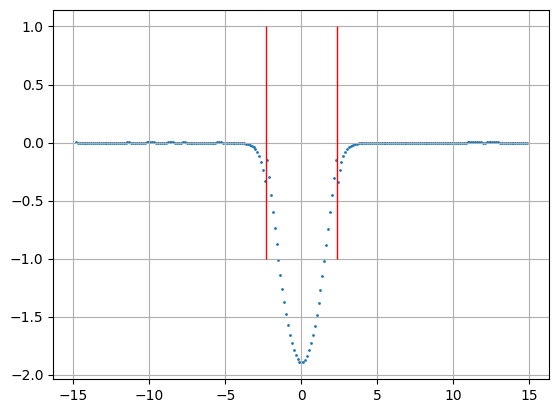

loss1 is  0.00016, loss2 is  0.00051, loss3 is  0.00008, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00011, total loss  0.00086, RI value  2.91049:  95%|█████████▌| 10500/11001 [20:48<00:58,  8.54it/s]

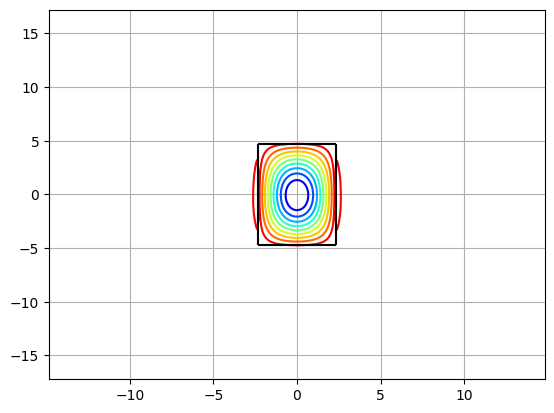

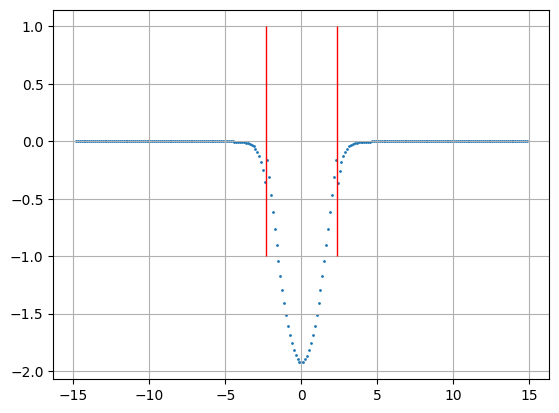

loss1 is  0.00033, loss2 is  0.00041, loss3 is  0.00017, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00010, total loss  0.00101, RI value  2.91012: 100%|█████████▉| 11000/11001 [21:48<00:00,  8.45it/s]

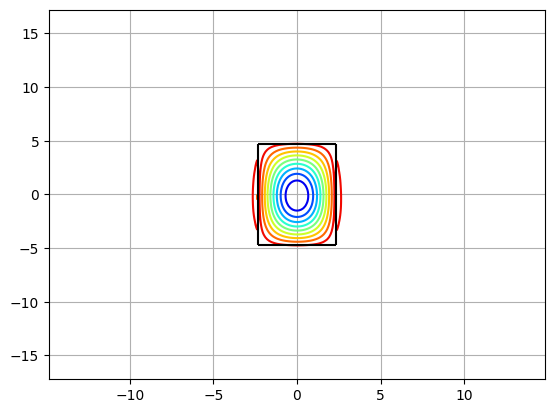

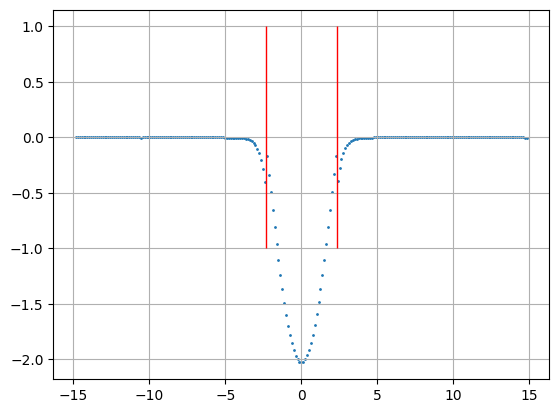

loss1 is  0.00033, loss2 is  0.00041, loss3 is  0.00017, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00010, total loss  0.00101, RI value  2.91012: 100%|██████████| 11001/11001 [21:49<00:00,  8.40it/s]


In [128]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(11001, num_modes, weights=weights, m=m, verbose=10, calc_error=False, plot_solution=True, sample_new=False)

In [129]:
base_model.to('cpu');
base_model.to(torch.float64);

In [130]:
# yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
# end_val_yu = yu[-1]
# yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
# end_val_yb = yb[-1]
# xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

# xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
# # if device.augmented_input:
# #   xy = torch.cat((xy, (1/reference_device.regions(xy, format='torch').view(-1, 1))), dim=-1)
# u = base_model.forward_with_features(xy.cpu()).cpu()

In [131]:
# plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
# plt.grid()

In [132]:
xy = torch.arange(0, device.total_length_x/2, dx/2, dtype=torch.float64).reshape(-1, 1)
xy = torch.cat((-torch.flip(xy, dims=(0,))[:-1], xy))

xy = torch.cat((xy, torch.full_like(xy, 0*dx)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, (reference_device.make_features(xy).view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()

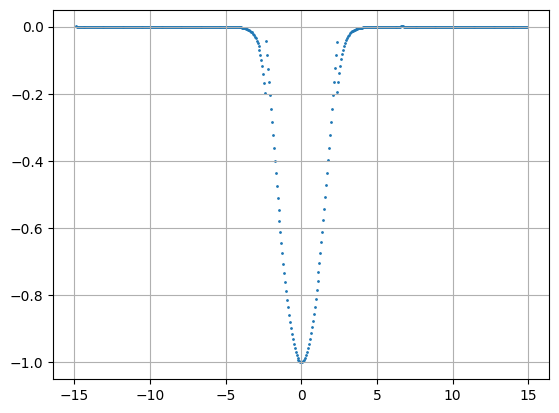

In [133]:
plt.scatter(xy[:, 0].cpu().detach(), u, s=1)
plt.grid()

In [134]:
len(xy[:])

475

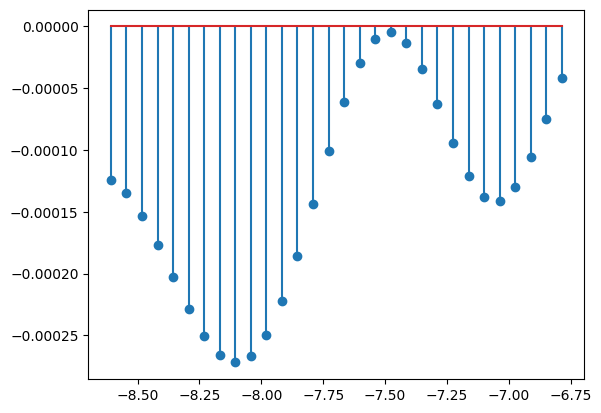

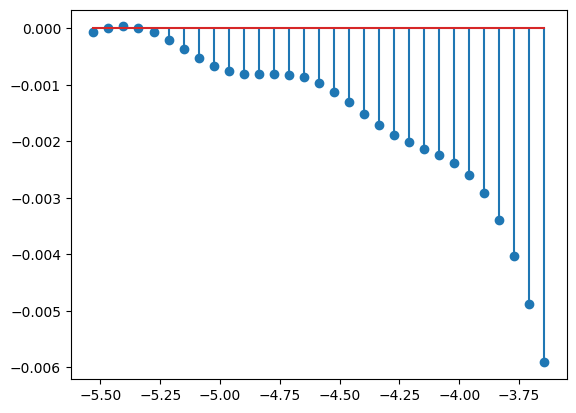

In [135]:
plt.stem(xy[2*50:2*65, 0].detach().numpy(), u[2*50:2*65, 0].detach().numpy())
plt.show()
plt.stem(xy[2*75-1:2*90, 0].detach().numpy(), u[2*75-1:2*90, 0].detach().numpy())
plt.show()

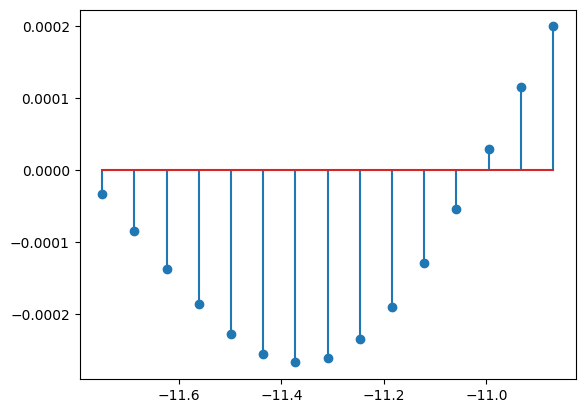

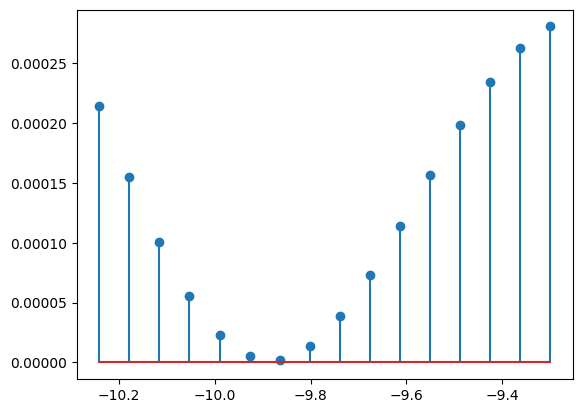

In [136]:
plt.stem(xy[50:65, 0].detach().numpy(), -u[50:65, 0].detach().numpy())
plt.show()
plt.stem(xy[75-1:90, 0].detach().numpy(), -u[75-1:90, 0].detach().numpy())
plt.show()

In [137]:
reference_device_fd = guides.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy)

In [138]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
print(np.sqrt(RI_squared))

[2.90922596]


In [139]:
xy_fd = torch.from_numpy(xy_fd).to(torch.float64)
xy = torch.cat((xy_fd, device.make_features(xy_fd)), dim=-1)
xy.requires_grad = True
NN_EI = [device.calculate_eigen_value(xy.to('cpu'), 0).item()**(1/2)]
print(NN_EI)
xy.requires_grad = False

[2.910863839015114]


In [140]:
reference_device_fd = guides.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx/2, dy/2)
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
print(np.sqrt(RI_squared))

[2.91130783]


In [141]:
xy_fd = torch.from_numpy(xy_fd).to(torch.float64)
xy = torch.cat((xy_fd, device.make_features(xy_fd)), dim=-1)
xy.requires_grad = True
NN_EI = [device.calculate_eigen_value(xy.to('cpu'), 0).item()**(1/2)]
print(NN_EI)
xy.requires_grad = False

[2.9108554272001808]


In [97]:
Nx = 2 * device.total_length_x // dx
Ny = 2 * device.total_length_y // dy

len(xy), Nx*Ny

(1155, 4550.0)

279
tensor([], dtype=torch.float64)


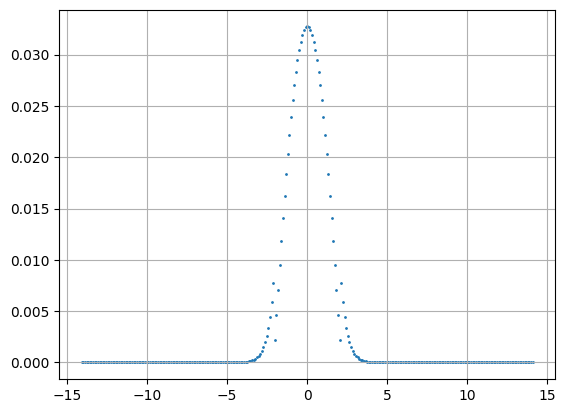

In [94]:
i = int(Ny/2)
row_length = int(Nx)
print(row_length)
print(xy_fd[len(u_fd) * i:len(u_fd) * (i + 1), 0])
plt.scatter(xy_fd[row_length * i: row_length * (i + 1), 0], u_fd[row_length * i:row_length * (i + 1), 0], s=1)
plt.grid()

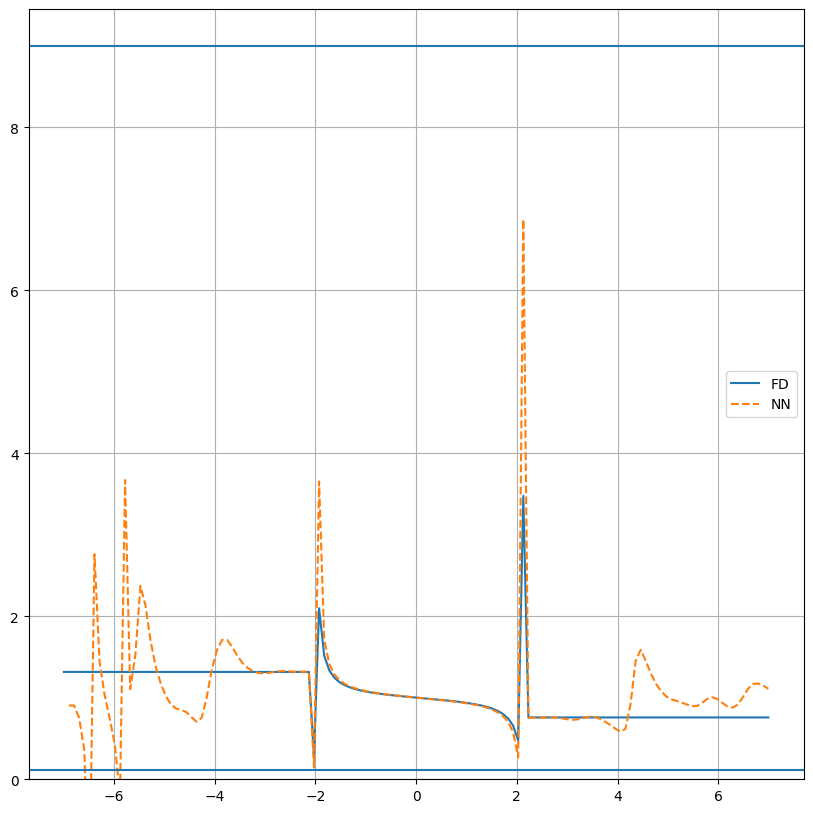

In [95]:
ratio_fd = u_fd[row_length * i:row_length * (i + 1), 0]/u_fd[row_length * i - 1: row_length * (i + 1)-1, 0]
half_index = len(ratio_fd)//2
quarter_index = len(ratio_fd)//4
xy_fd_slice = xy_fd[row_length * i:row_length * (i + 1)][half_index-quarter_index:half_index+quarter_index+1]

u = train_agent.evaluate(xy_fd_slice.cpu())[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()
ratio_nn = u[1:]/u[0:-1]

plt.figure(figsize=(10, 10))
plt.plot(xy_fd_slice[:, 0], ratio_fd[half_index-quarter_index:half_index+quarter_index+1], label='FD')

# plt.stem(xy[50:65, 0].detach().numpy(), -u[50:65, 0].detach().numpy())
# plt.show()
# plt.stem(xy[75-1:90, 0].detach().numpy(), -u[75-1:90, 0].detach().numpy())
# plt.show()
plt.plot(xy_fd_slice[1:, 0], ratio_nn, linestyle='--', label='NN')
plt.axhline(y=(n_core**2)/(n_substrate**2))
plt.axhline(y=(n_substrate**2)/(n_core**2))
plt.ylim([0, (n_core**2)/(n_substrate**2)*1.05])
plt.grid()
plt.legend()

In [96]:
u = base_model(xy.cpu())
u = u/torch.max(torch.abs(u))
u_fd = u_fd/np.max(np.abs(u_fd))

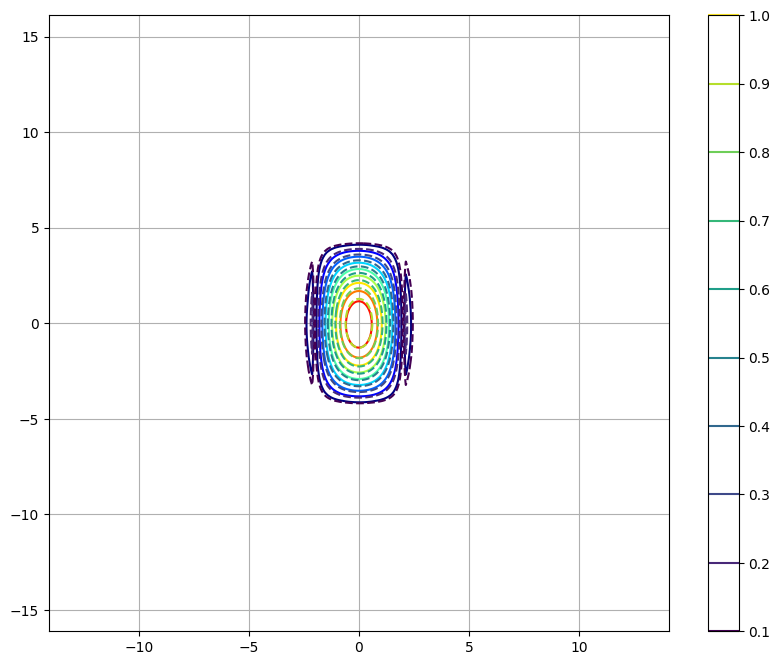

In [97]:
levels = np.linspace(0, np.max(np.abs(u_fd)), 11)[1:]
plt.figure(figsize=(10, 8))
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), cmap='jet', levels=levels)
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.colorbar()
plt.grid()

In [66]:
save_folder_path = r"C:\Users\asmaa\Desktop\Amr\2nd Paper\Experiments"

In [70]:
# np.save(save_folder_path + r'\NonPlanar\Single Mode High Contrast\DCNN_field.npy', u.detach().numpy())
# torch.save(base_model.state_dict(), save_folder_path + r'\NonPlanar\Single Mode High Contrast\DCNN.pty')
# np.save(save_folder_path + r'\NonPlanar\Single Mode High Contrast\NN_EI.npy', NN_EI)
 
# np.save(save_folder_path + r'\NonPlanar\Single Mode High Contrast\FD_field.npy', u_fd)
# np.save(save_folder_path + r'\NonPlanar\Single Mode High Contrast\FD_EI.npy', [RI_squared])